# Laboratorio 7 — Task 2.1 y 2.2
**CC3104 · Reinforcement Learning**  
Andy Fuentes (22944), Diederich Solís (22952), Diego Linares (221256)

Este cuaderno implementa DQN, Double DQN y Double DQN con *Prioritized Experience Replay* (PER) desde cero con PyTorch. Las figuras y cifras provienen de las ejecuciones que aparecen abajo. LunarLander es un entorno de prueba: sus recompensas no miden seguridad de redes.

## 1. Entorno y reproducibilidad
La guía pide `LunarLander-v2`. Antes de entrenar, verificamos que el identificador exista en la versión instalada de Gymnasium y que conserve una observación numérica de dimensión 8 y cuatro acciones discretas. Se usa CPU con un hilo para reducir diferencias entre ejecuciones. Cada método recibe la misma semilla de inicialización, los mismos estados iniciales por episodio y el mismo conjunto fijo de 100 estados para evaluar $Q$; las trayectorias pueden divergir porque sus políticas difieren.

In [1]:
import os
os.environ['PYGAME_HIDE_SUPPORT_PROMPT'] = '1'
from collections import deque
from dataclasses import dataclass
from pathlib import Path
import random
import time
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from IPython.display import display

torch.set_num_threads(1)
DEVICE = torch.device('cpu')
ENV_ID = 'LunarLander-v2'
assert ENV_ID in gym.registry, f'{ENV_ID} no está registrado en Gymnasium {gym.__version__}'
probe = gym.make(ENV_ID)
assert probe.observation_space.shape == (8,)
assert isinstance(probe.action_space, gym.spaces.Discrete) and probe.action_space.n == 4
observation, _ = probe.reset(seed=2026)
assert observation.shape == (8,)
print(f'Python/Gymnasium/PyTorch: {os.sys.version.split()[0]} / {gym.__version__} / {torch.__version__}')
print(f'Entorno verificado: {ENV_ID}; observación {probe.observation_space.shape}; acciones {probe.action_space.n}')
probe.close()

FIG_DIR = Path('figuras')
MET_DIR = Path('metricas')
FIG_DIR.mkdir(exist_ok=True)
MET_DIR.mkdir(exist_ok=True)

Python/Gymnasium/PyTorch: 3.12.3 / 0.29.1 / 2.12.0
Entorno verificado: LunarLander-v2; observación (8,); acciones 4


### Diseño experimental e hiperparámetros
Los parámetros exigidos por la guía están fijados en la configuración. Elegimos además $\gamma=0.99$, Adam con tasa $5\times10^{-4}$, un calentamiento de 1 000 transiciones, una actualización de gradiente cada cuatro pasos y recorte de norma del gradiente a 10. Estas decisiones son comunes para estabilizar el entrenamiento y son idénticas en los tres métodos. Se ejecuta **una semilla** y 500 episodios por método; los resultados no deben leerse como una comparación estadística entre semillas. La truncación por límite de tiempo finaliza el episodio, pero no se trata como un estado terminal en el target.

La exploración usa $\epsilon_t=1-0.95\min(t/10\,000,1)$. La red objetivo se copia cada 500 pasos del entorno. El valor $Q$ registrado al final de cada episodio es $\frac1{100}\sum_{s\in S_{\rm fijo}}\max_a Q(s,a;w)$, donde $S_{\rm fijo}$ se crea **antes** de entrenar. El target promedio de un episodio promedia los targets de todos sus minibatches; queda sin valor cuando todavía no hay actualizaciones.

In [2]:
@dataclass(frozen=True)
class Config:
    episodes: int = 500
    seed: int = 2026
    hidden: int = 128
    capacity: int = 50_000
    batch_size: int = 64
    target_sync_steps: int = 500
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 10_000
    gamma: float = 0.99
    learning_rate: float = 5e-4
    learning_starts: int = 1_000
    train_every: int = 4
    grad_clip: float = 10.0
    per_alpha: float = 0.6
    per_beta_start: float = 0.4
    per_beta_end: float = 1.0
    per_priority_eps: float = 1e-5

CFG = Config()
print(CFG)

# Muestras de trayectorias aleatorias independientes del entrenamiento.
# Se fijan antes de construir cualquiera de las tres redes.
eval_rng = np.random.default_rng(9091)
eval_env = gym.make(ENV_ID)
pool = []
episode_number = 0
while len(pool) < 2_000:
    state, _ = eval_env.reset(seed=90_000 + episode_number)
    done = False
    while not done and len(pool) < 2_000:
        pool.append(np.asarray(state, dtype=np.float32).copy())
        action = int(eval_rng.integers(4))
        state, _, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
    episode_number += 1
eval_env.close()
indices = eval_rng.choice(len(pool), size=100, replace=False)
EVAL_STATES = np.stack([pool[i] for i in indices]).astype(np.float32)
np.save(MET_DIR / 'estados_evaluacion_100.npy', EVAL_STATES)
assert EVAL_STATES.shape == (100, 8)
print('Estados de evaluación fijados:', EVAL_STATES.shape,
      'procedentes de', episode_number, 'episodios aleatorios')

Config(episodes=500, seed=2026, hidden=128, capacity=50000, batch_size=64, target_sync_steps=500, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_steps=10000, gamma=0.99, learning_rate=0.0005, learning_starts=1000, train_every=4, grad_clip=10.0, per_alpha=0.6, per_beta_start=0.4, per_beta_end=1.0, per_priority_eps=1e-05)
Estados de evaluación fijados: (100, 8) procedentes de 22 episodios aleatorios


## 2. Redes, replay y targets
La red recibe ocho valores continuos y emite cuatro valores $Q$. Tiene exactamente dos capas ocultas de 128 unidades ReLU. DQN usa $y=r+\gamma(1-d)\max_{a'}Q(s',a';w^-)$; Double DQN selecciona $a^*=\arg\max_{a'}Q(s',a';w)$ con la red en línea y evalúa $Q(s',a^*;w^-)$ con la red objetivo. La pérdida cuadrática ajusta $Q(s,a;w)$ al target.

In [3]:
class QNetwork(nn.Module):
    def __init__(self, observation_dim=8, actions=4, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(observation_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, actions),
        )

    def forward(self, states):
        return self.net(states)


class ReplayBuffer:
    """Buffer circular FIFO de 50 000 transiciones; el muestreo uniforme es sin reemplazo."""
    def __init__(self, capacity, state_dim=8):
        self.capacity = capacity
        self.states = np.empty((capacity, state_dim), dtype=np.float32)
        self.next_states = np.empty((capacity, state_dim), dtype=np.float32)
        self.actions = np.empty(capacity, dtype=np.int64)
        self.rewards = np.empty(capacity, dtype=np.float32)
        self.terminals = np.empty(capacity, dtype=np.float32)
        self.size = 0
        self.position = 0

    def __len__(self):
        return self.size

    def add(self, state, action, reward, next_state, terminated):
        i = self.position
        self.states[i] = state
        self.actions[i] = action
        self.rewards[i] = reward
        self.next_states[i] = next_state
        self.terminals[i] = float(terminated)
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
        return i

    def batch(self, indices):
        return (
            torch.as_tensor(self.states[indices], device=DEVICE),
            torch.as_tensor(self.actions[indices], device=DEVICE),
            torch.as_tensor(self.rewards[indices], device=DEVICE),
            torch.as_tensor(self.next_states[indices], device=DEVICE),
            torch.as_tensor(self.terminals[indices], device=DEVICE),
        )

    def sample(self, batch_size, rng):
        indices = rng.choice(self.size, size=batch_size, replace=False)
        weights = torch.ones(batch_size, dtype=torch.float32, device=DEVICE)
        return indices, self.batch(indices), weights


def td_targets(online, target, rewards, next_states, terminals, gamma, double):
    # Diapositivas: w^- fija la evaluación; Double cambia SOLO la selección.
    with torch.no_grad():
        target_next = target(next_states)
        if double:
            next_actions = online(next_states).argmax(dim=1, keepdim=True)
            next_q = target_next.gather(1, next_actions).squeeze(1)
        else:
            next_q = target_next.max(dim=1).values
        return rewards + gamma * (1.0 - terminals) * next_q

### Prioritized Experience Replay
Para cada transición $i$ guardamos $p_i=|\delta_i|+\varepsilon_p$, con $\delta_i=y_i-Q(s_i,a_i;w)$ y $\varepsilon_p=10^{-5}$. El árbol de sumas almacena $p_i^{\alpha}$; el muestreo estratificado proporcional asigna $P(i)=p_i^{\alpha}/\sum_j p_j^{\alpha}$, con $\alpha=0.6$. Los pesos de importancia son $w_i=(NP(i))^{-\beta}/\max_j(NP(j))^{-\beta}$; un árbol de mínimos da el máximo global para normalizarlos. $\beta$ crece linealmente **por episodio** de 0.4 a 1.0, alcanzando 1.0 en el último episodio. Las nuevas transiciones entran con la mayor prioridad observada para que puedan ser examinadas.

In [4]:
class PrioritizedReplayBuffer(ReplayBuffer):
    def __init__(self, capacity, alpha=0.6, priority_eps=1e-5, state_dim=8):
        super().__init__(capacity, state_dim)
        self.alpha = alpha
        self.priority_eps = priority_eps
        self.leaves = 1 << (capacity - 1).bit_length()
        self.sum_tree = np.zeros(2 * self.leaves, dtype=np.float64)
        self.min_tree = np.full(2 * self.leaves, np.inf, dtype=np.float64)
        self.max_raw_priority = 1.0

    def _set_priority(self, i, raw_priority):
        scaled = float(raw_priority) ** self.alpha
        node = self.leaves + int(i)
        self.sum_tree[node] = scaled
        self.min_tree[node] = scaled
        while node > 1:
            node //= 2
            self.sum_tree[node] = self.sum_tree[2 * node] + self.sum_tree[2 * node + 1]
            self.min_tree[node] = min(self.min_tree[2 * node], self.min_tree[2 * node + 1])

    def add(self, state, action, reward, next_state, terminated):
        i = super().add(state, action, reward, next_state, terminated)
        self._set_priority(i, self.max_raw_priority)
        return i

    def sample(self, batch_size, rng, beta):
        total = self.sum_tree[1]
        indices = np.empty(batch_size, dtype=np.int64)
        probs = np.empty(batch_size, dtype=np.float64)
        for j in range(batch_size):
            # Un intervalo por muestra; puede haber duplicados como en PER habitual.
            mass = (j + rng.random()) * total / batch_size
            node = 1
            while node < self.leaves:
                left = 2 * node
                if mass < self.sum_tree[left]:
                    node = left
                else:
                    mass -= self.sum_tree[left]
                    node = left + 1
            i = node - self.leaves
            assert i < self.size
            indices[j] = i
            probs[j] = self.sum_tree[node] / total
        min_prob = self.min_tree[1] / total
        max_weight = (self.size * min_prob) ** (-beta)
        weights = (self.size * probs) ** (-beta) / max_weight
        return indices, self.batch(indices), torch.as_tensor(weights, dtype=torch.float32, device=DEVICE)

    def update_priorities(self, indices, absolute_td_errors):
        # Repeticiones del mismo índice reciben el error TD máximo del lote.
        combined = {}
        for i, error in zip(indices, absolute_td_errors):
            i = int(i)
            combined[i] = max(combined.get(i, 0.0), float(error))
        for i, error in combined.items():
            raw = max(error + self.priority_eps, self.priority_eps)
            self.max_raw_priority = max(self.max_raw_priority, raw)
            self._set_priority(i, raw)

### Verificaciones pequeñas antes de entrenar
La primera prueba usa redes artificiales con preferencias opuestas: DQN debe tomar el máximo de la red objetivo, mientras Double DQN debe usar el índice seleccionado por la red en línea. La segunda verifica que el árbol PER conserva probabilidades positivas y pesos finitos. Son comprobaciones del cálculo, no resultados experimentales de LunarLander.

In [5]:
class FixedQ(nn.Module):
    def __init__(self, values):
        super().__init__()
        self.register_buffer('values', torch.tensor(values, dtype=torch.float32))
    def forward(self, x):
        return self.values.repeat(len(x), 1)

online_test = FixedQ([10, 0, 0, 0])
target_test = FixedQ([0, 5, 1, 2])
zero = torch.zeros(1)
state_test = torch.zeros(1, 8)
assert td_targets(online_test, target_test, zero, state_test, zero, 1.0, False).item() == 5.0
assert td_targets(online_test, target_test, zero, state_test, zero, 1.0, True).item() == 0.0
assert td_targets(online_test, target_test, torch.tensor([7.]), state_test,
                  torch.ones(1), 1.0, True).item() == 7.0
test_buffer = PrioritizedReplayBuffer(4)
for i in range(4):
    test_buffer.add(np.zeros(8, np.float32), 0, 0., np.zeros(8, np.float32), False)
test_buffer.update_priorities(np.arange(4), np.array([1., 2., 3., 4.]))
test_indices, _, test_weights = test_buffer.sample(4, np.random.default_rng(7), beta=0.7)
assert np.all(test_indices < 4) and torch.isfinite(test_weights).all()
assert 0 < test_weights.min() <= test_weights.max() <= 1
print('Targets DQN/Double y muestreo PER: comprobaciones superadas.')

Targets DQN/Double y muestreo PER: comprobaciones superadas.


## 3. Entrenamiento
Cada método ejecuta exactamente el mismo procedimiento salvo la fórmula del target o el mecanismo de replay. El buffer se llena antes del primer gradiente; se almacena cada transición, aun cuando no se actualice la red. El registro por episodio incluye recompensa, media de $\max_a Q$ sobre los 100 estados fijos y media de targets realmente usados. En PER, la pérdida cuadrática se pondera con los pesos de importancia y las prioridades se actualizan con el error TD calculado antes del paso de gradiente.

In [6]:
def epsilon_at(step, cfg):
    fraction = min(step / cfg.epsilon_decay_steps, 1.0)
    return cfg.epsilon_start + fraction * (cfg.epsilon_end - cfg.epsilon_start)


def beta_at(episode_index, cfg):
    fraction = episode_index / (cfg.episodes - 1)
    return cfg.per_beta_start + fraction * (cfg.per_beta_end - cfg.per_beta_start)


def train_agent(name, cfg, eval_states):
    assert name in ('DQN', 'Double DQN', 'Double DQN + PER')
    use_double = name != 'DQN'
    use_per = name.endswith('PER')
    random.seed(cfg.seed)
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed + 13)
    env = gym.make(ENV_ID)
    env.action_space.seed(cfg.seed)
    online = QNetwork(hidden=cfg.hidden).to(DEVICE)
    target = QNetwork(hidden=cfg.hidden).to(DEVICE)
    target.load_state_dict(online.state_dict())
    target.eval()
    optimizer = torch.optim.Adam(online.parameters(), lr=cfg.learning_rate)
    replay = (PrioritizedReplayBuffer(cfg.capacity, cfg.per_alpha, cfg.per_priority_eps)
              if use_per else ReplayBuffer(cfg.capacity))
    eval_tensor = torch.as_tensor(eval_states, dtype=torch.float32, device=DEVICE)
    rows = []
    total_steps = 0
    start_time = time.perf_counter()

    for episode in range(cfg.episodes):
        state, _ = env.reset(seed=cfg.seed + episode)
        episode_reward = 0.0
        episode_targets = []
        updates = 0
        episode_steps = 0
        beta = beta_at(episode, cfg) if use_per else np.nan
        while True:
            eps = epsilon_at(total_steps, cfg)
            if rng.random() < eps:
                action = int(rng.integers(4))
            else:
                with torch.no_grad():
                    x = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                    action = int(online(x).argmax(dim=1).item())
            next_state, reward, terminated, truncated, _ = env.step(action)
            # Sólo terminated apaga el bootstrap. TimeLimit/truncated corta el episodio.
            replay.add(state, action, reward, next_state, terminated)
            state = next_state
            episode_reward += float(reward)
            episode_steps += 1
            total_steps += 1

            if len(replay) >= cfg.learning_starts and total_steps % cfg.train_every == 0:
                if use_per:
                    sampled_indices, batch, weights = replay.sample(cfg.batch_size, rng, beta)
                else:
                    sampled_indices, batch, weights = replay.sample(cfg.batch_size, rng)
                states_b, actions_b, rewards_b, next_states_b, terminals_b = batch
                targets_b = td_targets(online, target, rewards_b, next_states_b,
                                       terminals_b, cfg.gamma, use_double)
                current_q = online(states_b).gather(1, actions_b.unsqueeze(1)).squeeze(1)
                td_error = targets_b - current_q
                loss = (weights * td_error.square()).mean()
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(online.parameters(), cfg.grad_clip)
                optimizer.step()
                if use_per:
                    replay.update_priorities(sampled_indices, td_error.detach().abs().cpu().numpy())
                episode_targets.append(float(targets_b.mean().item()))
                updates += 1

            if total_steps % cfg.target_sync_steps == 0:
                target.load_state_dict(online.state_dict())
            if terminated or truncated:
                break

        with torch.no_grad():
            q_eval = online(eval_tensor).max(dim=1).values.mean().item()
        rows.append({
            'episode': episode + 1,
            'reward': episode_reward,
            'q_eval': q_eval,
            'target_mean': float(np.mean(episode_targets)) if episode_targets else np.nan,
            'updates': updates,
            'steps': episode_steps,
            'total_steps': total_steps,
            'epsilon_end': epsilon_at(total_steps, cfg),
            'beta': beta,
        })
        if (episode + 1) % 50 == 0 or episode == 0:
            recent = np.mean([row['reward'] for row in rows[-20:]])
            elapsed = time.perf_counter() - start_time
            print(f'{name:18s} ep {episode+1:3d}/{cfg.episodes} '
                  f'pasos {total_steps:6d} media20 {recent:8.1f} tiempo {elapsed:6.1f}s')
            Path('.progreso_entrenamiento.txt').write_text(
                f'{name} | episodio {episode+1}/{cfg.episodes} | pasos {total_steps} | '
                f'media20 {recent:.1f} | tiempo {elapsed:.1f}s\n', encoding='utf-8')

    env.close()
    frame = pd.DataFrame(rows)
    frame['reward_ma20'] = frame.reward.rolling(20, min_periods=20).mean()
    safe_name = name.lower().replace(' ', '_').replace('+', 'per')
    frame.to_csv(MET_DIR / f'{safe_name}.csv', index=False)
    print(f'{name}: {total_steps} pasos, {int(frame.updates.sum())} actualizaciones, '
          f'{time.perf_counter()-start_time:.1f} s.')
    return frame, online

In [7]:
metrics_dqn, net_dqn = train_agent('DQN', CFG, EVAL_STATES)

DQN                ep   1/500 pasos    112 media20   -180.9 tiempo    0.0s


DQN                ep  50/500 pasos   6347 media20    -98.3 tiempo    0.8s


DQN                ep 100/500 pasos  50578 media20    -29.0 tiempo    7.0s


DQN                ep 150/500 pasos  98479 media20    -12.1 tiempo   13.4s


DQN                ep 200/500 pasos 141344 media20     90.9 tiempo   19.2s


...

DQN                ep 350/500 pasos 213858 media20    237.6 tiempo   28.6s


DQN                ep 400/500 pasos 230437 media20    228.3 tiempo   32.1s


DQN                ep 450/500 pasos 246853 media20    234.1 tiempo   37.3s


DQN                ep 500/500 pasos 260790 media20    243.2 tiempo   41.4s


DQN: 260790 pasos, 64948 actualizaciones, 42.0 s.


In [8]:
metrics_double, net_double = train_agent('Double DQN', CFG, EVAL_STATES)

Double DQN         ep   1/500 pasos    112 media20   -180.9 tiempo    0.0s


Double DQN         ep  50/500 pasos   7466 media20   -130.8 tiempo    1.8s


Double DQN         ep 100/500 pasos  41050 media20     16.2 tiempo   10.2s


Double DQN         ep 150/500 pasos  82189 media20     44.1 tiempo   18.9s


Double DQN         ep 200/500 pasos 130515 media20     -8.9 tiempo   28.8s


...

Double DQN         ep 300/500 pasos 201888 media20     38.5 tiempo   39.6s


Double DQN         ep 350/500 pasos 235489 media20    114.6 tiempo   44.6s


Double DQN         ep 400/500 pasos 263727 media20    204.7 tiempo   49.6s


Double DQN         ep 450/500 pasos 293847 media20    192.1 tiempo   54.5s


Double DQN         ep 500/500 pasos 317678 media20    237.7 tiempo   58.2s
Double DQN: 317678 pasos, 79170 actualizaciones, 58.4 s.


In [9]:
metrics_per, net_per = train_agent('Double DQN + PER', CFG, EVAL_STATES)
Path('.progreso_entrenamiento.txt').unlink(missing_ok=True)

Double DQN + PER   ep   1/500 pasos    112 media20   -180.9 tiempo    0.0s


Double DQN + PER   ep  50/500 pasos   5654 media20   -157.8 tiempo    1.4s


Double DQN + PER   ep 100/500 pasos  33810 media20     -0.6 tiempo    9.7s


Double DQN + PER   ep 150/500 pasos  77637 media20    -36.2 tiempo   22.8s


Double DQN + PER   ep 200/500 pasos 120736 media20     66.5 tiempo   35.7s


...

Double DQN + PER   ep 300/500 pasos 172661 media20    168.9 tiempo   50.9s


Double DQN + PER   ep 350/500 pasos 192465 media20    236.4 tiempo   56.8s


Double DQN + PER   ep 400/500 pasos 210434 media20    234.6 tiempo   62.1s


Double DQN + PER   ep 450/500 pasos 229491 media20    218.1 tiempo   67.8s


Double DQN + PER   ep 500/500 pasos 252426 media20    234.6 tiempo   74.5s
Double DQN + PER: 252426 pasos, 62857 actualizaciones, 74.5 s.


## 4. Figuras y medidas observadas
Las curvas tenues muestran recompensa por episodio; las líneas gruesas son medias móviles de 20 episodios. No suavizamos los valores $Q$ que se comparan en los mismos 100 estados. El target promedio se dibuja como diagnóstico adicional. La media de los 20 últimos episodios se usa como una medida descriptiva de la fase final, sin presentarla como una estimación precisa de desempeño general.

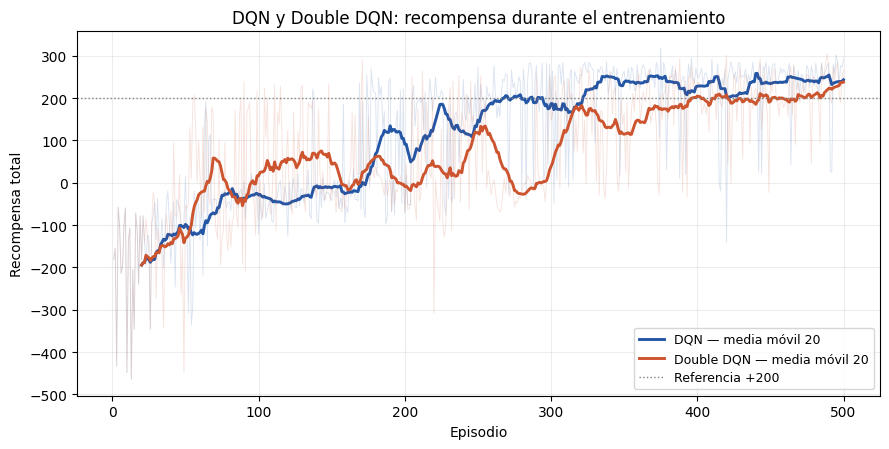

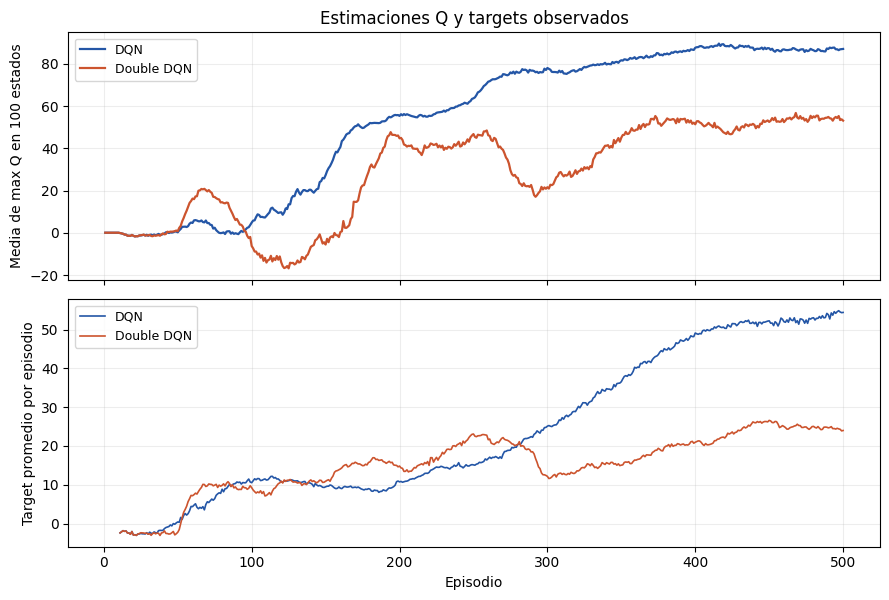

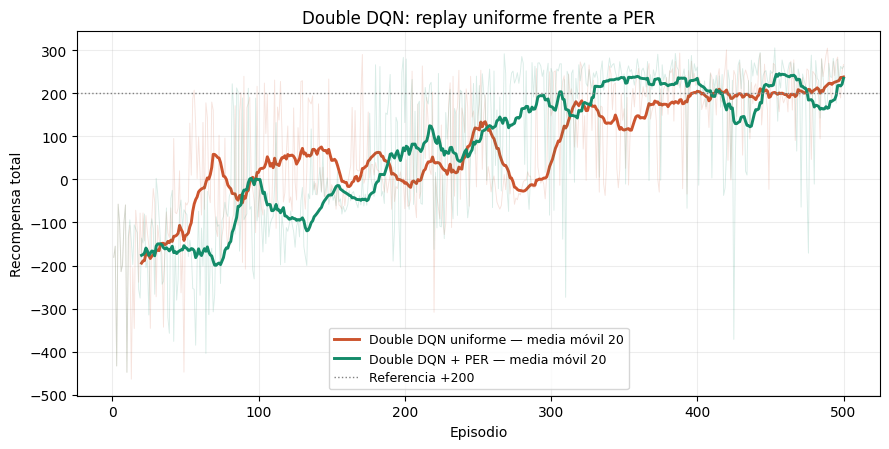

In [10]:
def plot_rewards(series, labels, colors, title, filename):
    fig, ax = plt.subplots(figsize=(9, 4.6))
    for data, label, color in zip(series, labels, colors):
        ax.plot(data.episode, data.reward, color=color, alpha=0.16, linewidth=0.65)
        ax.plot(data.episode, data.reward_ma20, color=color, linewidth=2.1,
                label=f'{label} — media móvil 20')
    ax.axhline(200, color='gray', linestyle=':', linewidth=1, label='Referencia +200')
    ax.set(xlabel='Episodio', ylabel='Recompensa total', title=title)
    ax.grid(alpha=0.22)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=180)
    plt.show()
    plt.close(fig)

plot_rewards([metrics_dqn, metrics_double], ['DQN', 'Double DQN'],
             ['#2456a6', '#cc542e'],
             'DQN y Double DQN: recompensa durante el entrenamiento',
             'recompensa_dqn_vs_double.png')

fig, axes = plt.subplots(2, 1, figsize=(9, 6.1), sharex=True)
for data, label, color in [(metrics_dqn, 'DQN', '#2456a6'),
                           (metrics_double, 'Double DQN', '#cc542e')]:
    axes[0].plot(data.episode, data.q_eval, label=label, color=color, linewidth=1.6)
    axes[1].plot(data.episode, data.target_mean, label=label, color=color, linewidth=1.2)
axes[0].set_ylabel('Media de max Q en 100 estados')
axes[1].set_ylabel('Target promedio por episodio')
axes[1].set_xlabel('Episodio')
axes[0].set_title('Estimaciones Q y targets observados')
for ax in axes:
    ax.grid(alpha=0.22)
    ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'q_y_targets_dqn_vs_double.png', dpi=180)
plt.show()
plt.close(fig)

plot_rewards([metrics_double, metrics_per], ['Double DQN uniforme', 'Double DQN + PER'],
             ['#cc542e', '#138b69'],
             'Double DQN: replay uniforme frente a PER',
             'recompensa_double_vs_per.png')

In [11]:
def first_threshold(data, threshold=200):
    hit = data.loc[data.reward_ma20 >= threshold, 'episode']
    return int(hit.iloc[0]) if len(hit) else 'no alcanzado'

summary = []
for label, data in [('DQN', metrics_dqn), ('Double DQN', metrics_double),
                    ('Double DQN + PER', metrics_per)]:
    summary.append({
        'método': label,
        'episodios': len(data),
        'pasos': int(data.steps.sum()),
        'recompensa primeros 20': round(data.reward.head(20).mean(), 2),
        'recompensa últimos 20': round(data.reward.tail(20).mean(), 2),
        'mejor media móvil 20': round(data.reward_ma20.max(), 2),
        'primera media móvil >= 200': first_threshold(data),
        'Q promedio últimos 20': round(data.q_eval.tail(20).mean(), 2),
        'target promedio últimos 20': round(data.target_mean.tail(20).mean(), 2),
    })
summary_frame = pd.DataFrame(summary)
display(summary_frame)
summary_frame.to_csv(MET_DIR / 'resumen.csv', index=False)

phase_rows = []
for label, data in [('DQN', metrics_dqn), ('Double DQN', metrics_double),
                    ('Double DQN + PER', metrics_per)]:
    for start, end in [(1, 100), (101, 250), (251, 400), (401, 500)]:
        part = data[(data.episode >= start) & (data.episode <= end)]
        phase_rows.append({'método': label, 'episodios': f'{start}-{end}',
                           'recompensa media': round(part.reward.mean(), 2),
                           'Q medio': round(part.q_eval.mean(), 2)})
phase_frame = pd.DataFrame(phase_rows)
display(phase_frame)
phase_frame.to_csv(MET_DIR / 'resumen_fases.csv', index=False)

,método,episodios,pasos,recompensa primeros 20,recompensa últimos 20,mejor media móvil 20,primera media móvil >= 200,Q promedio últimos 20,target promedio últimos 20
0,DQN,500,260790,-194.39,243.16,258.40,269,86.77,53.74
1,Double DQN,500,317678,-194.32,237.75,237.75,397,54.24,24.55
2,Double DQN + PER,500,252426,-176.16,234.61,245.56,306,27.13,60.56


,método,episodios,recompensa media,Q medio
0,DQN,1-100,-97.11,0.92
1,DQN,101-250,56.69,40.16
2,DQN,251-400,216.19,78.84
3,DQN,401-500,236.06,87.32
4,Double DQN,1-100,-72.40,5.40
5,Double DQN,101-250,41.00,17.42
6,Double DQN,251-400,117.44,38.90
7,Double DQN,401-500,206.96,52.19
8,Double DQN + PER,1-100,-131.73,1.81
9,Double DQN + PER,101-250,7.21,48.18


### Interpretación y límites
Los valores $Q$ son predicciones internas; sin retornos reales de referencia para esos 100 estados, una curva mayor **no prueba por sí sola** sobreestimación. Una semilla tampoco permite atribuir una diferencia de recompensa únicamente al algoritmo. La comparación con PER sirve para este entorno y régimen de entrenamiento; en redes reales habría que modelar eventos críticos, costos, retrasos y cambio de distribución antes de extrapolar.